In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
from STiMetaD import STiMetaD

In [5]:


# Was broken: 'YYDPETGRWY',
proteins = ['chignolin', 'YYDPETGTWE', 'YYRPETGTWY', 'YYAPETGTWY', 'YYDPETGQWY', 'YYDPETGTWG', 'YYDPETGTWQ', 'YYNPETGTWY', 'YYEPETGTWY', 'YYDPETGTWR', 'YYCPETGTWY', 'YYDPETGVWY', 'YYDPETGYWY', 'YYDPETGTWV', 'YYDPETGRWY']

thresholds = np.arange(0.16, 0.50, 0.04)
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    colnames = ["time", "hlda", "metad.bias", "metad.acc", "rmsd"]

    for i in range(4000, 4200):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"

        try:
            df = pd.read_csv(run_path, sep=r"\s+", comment="#", names=colnames, engine="python")
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue

        passed = set()
        for idx, row in df.iterrows():
            rmsd = row["rmsd"]
            time = row["time"]
            acc = row["metad.acc"]
            predicted = time * acc

            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break

print(all_mfpt)

Missing: ../data/YYDPETGTWV/output/run_4145/HLDA_COLVAR_4145
Missing: ../data/YYDPETGTWV/output/run_4147/HLDA_COLVAR_4147
Missing: ../data/YYDPETGTWV/output/run_4150/HLDA_COLVAR_4150
Missing: ../data/YYDPETGTWV/output/run_4157/HLDA_COLVAR_4157
{'chignolin': {np.float64(0.16): [np.float64(153219065.490666), np.float64(162363362.7265), np.float64(40409466.506520994), np.float64(96905191.02891), np.float64(464479531.040052), np.float64(190865.604072), np.float64(1438765.8528719998), np.float64(1852793.02041), np.float64(112234164.35467), np.float64(3910400.830956), np.float64(190956371.86085302), np.float64(22905189.823859), np.float64(343041.634248), np.float64(3372173537.56255), np.float64(27799827.085440002), np.float64(325255.86865200003), np.float64(313755239741.81537), np.float64(9795326.572048), np.float64(617379086.3310001), np.float64(75437549.304516), np.float64(7283.845528000001), np.float64(122450.317626), np.float64(626990439.2002571), np.float64(1357243.88031), np.float64(21

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
# Original: YYDPETGTWY
mutation_map = {
    "YYAPETGTWY": "D2A",
    "YYCPETGTWY": "D2C",
    "YYMPETGTWY": "D2M",
    "YYNPETGTWY": "D2N",
    "YYRPETGTWY": "D2R",
    "YYEPETGTWY": "D2E",
    "YYDPETGTWE": "Y9E",
    "YYDPETGTWG": "Y9G",
    "YYDPETGTWQ": "Y9Q",
    "YYDPETGTWR": "Y9R",
    "YYDPETGTWV": "Y9V",
    "YYDPETGTWA": "Y9A",
    "YYDPETGVWY": "T7V",
    "YYDPETGQWY": "T7Q",
    "YYDPETGRWY": "T7R",
    "YYDPETGYWY": "T7Y",
    "chignolin": "Wildtype"
}

estimator = STiMetaD(minSampleSize=5)
data = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
th = thresholds[0]

sample_size = 30
dots = []
mfpts = []
chig_sorted = np.sort(all_mfpt['chignolin'][th])[:sample_size]
chig_mfpt, _ = estimator.iMetaDMFPT(chig_sorted, KStest=True)

for protein in proteins[1:]:
    short_protein = mutation_map.get(protein)
    
    s = np.sort(all_mfpt[protein][th])[:sample_size]
    mfpt, p = estimator.iMetaDMFPT(s, KStest=True)

    print(f"Protein: {protein}, MFPT: {mfpt:.2g} s, p-value: {p:.3g}")
    
    if short_protein is None:
        print(f"Mutation {protein} not found in the mapping.")
        continue
    
    mfpts.append(mfpt)
    dots.append(data.loc[short_protein, "full_evec_dot"])
    


plt.xlabel('Dot Product')
# plt.ylabel('log(abs(MFPT(Mutation - WT)) (µs)')
# plt.yscale('log')
y = np.abs(mfpts - chig_mfpt) / 1e6
# y = np.array(mfpts) / 1e6
plt.scatter(dots, y)

for i, protein in enumerate(proteins[1:]):
    plt.text(dots[i], y[i], protein, fontsize=6, ha='center', va='center')
    

# plt.axhline(y=chig_mfpt / 1e6, linestyle='--', color='lightblue', label='Chignolin MFPT')
plt.legend()


from scipy import stats

pearson, _ = stats.pearsonr(dots, y)
spearman, _ = stats.spearmanr(dots, y)

plt.title(f"Pearson: {pearson:.3g}, Spearman: {spearman:.3g}")

NameError: name 'thresholds' is not defined

/rg/mendels_prj/alexander.z/protein-toolkit/src/STiMetaD.py:20: RuntimeWarning: overflow encountered in exp
  return 1 - np.exp(-t / a)


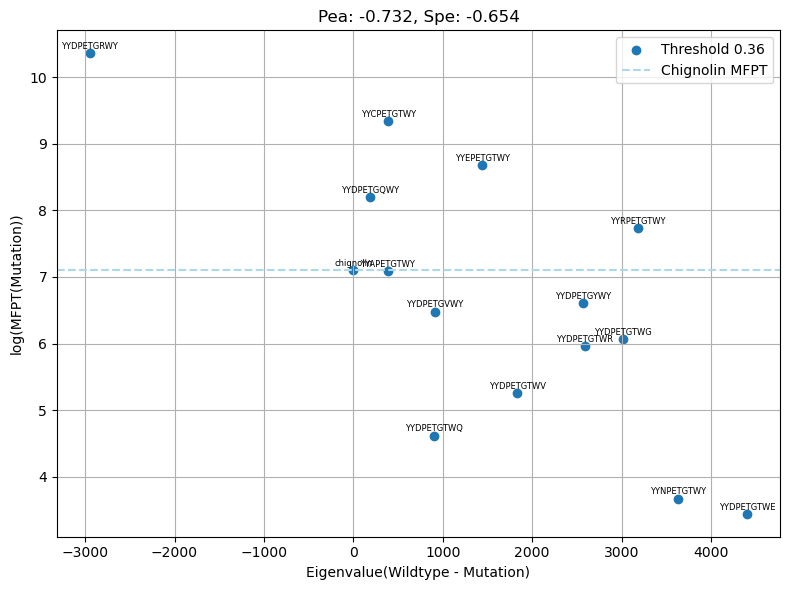

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
wt_eigenvalue = data.loc['Wildtype', 'eigenvalue']

def collect_data(th: float, sample_size: int):
    eigenvalue_delta = []
    mfpts = []
    chig_sorted = np.sort(all_mfpt['chignolin'][th])[:sample_size]
    chig_mfpt, _ = estimator.iMetaDMFPT(chig_sorted, KStest=True)

    for protein in proteins:
        short_protein = mutation_map.get(protein)

        s = np.sort(all_mfpt[protein][th])[:sample_size]
        mfpt, p = estimator.iMetaDMFPT(s, KStest=True)

        if short_protein is None:
            continue

        mfpts.append(mfpt)
        eigenvalue_delta.append(wt_eigenvalue - data.loc[short_protein, "eigenvalue"])

    x = np.array(eigenvalue_delta)
    y = np.log(np.array(mfpts) / 1e6)
    return x, y, chig_mfpt

th =  thresholds[5]
x1, y1, chig1 = collect_data(th, 200)

plt.figure(figsize=(8, 6))
plt.xlabel('Eigenvalue(Wildtype - Mutation)')
plt.ylabel('log(MFPT(Mutation))')

plt.scatter(x1, y1, label=f'Threshold {th:.3g}')

for i, protein in enumerate(proteins):
    plt.text(x1[i], y1[i] + 0.1, protein, fontsize=6, ha='center', va='center')

plt.axhline(y=np.log(chig1 / 1e6), linestyle='--', color='lightblue', label='Chignolin MFPT')

pearson, _ = stats.pearsonr(x1, y1)
spearman, _ = stats.spearmanr(x1, y1)

plt.title(f"Pea: {pearson:.3g}, Spe: {spearman:.3g}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


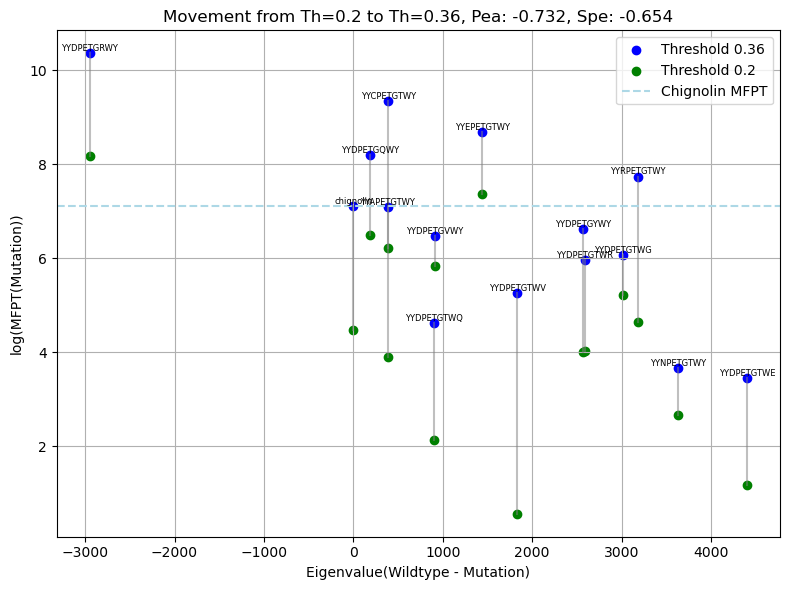

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def collect_data(th: float, sample_size: int):
    eigenvalue_delta = []
    mfpts = []
    chig_sorted = np.sort(all_mfpt['chignolin'][th])[:sample_size]
    chig_mfpt, _ = estimator.iMetaDMFPT(chig_sorted, KStest=True)

    for protein in proteins:
        short_protein = mutation_map.get(protein)

        s = np.sort(all_mfpt[protein][th])[:sample_size]
        mfpt, p = estimator.iMetaDMFPT(s, KStest=True)

        if short_protein is None:
            continue

        mfpts.append(mfpt)
        eigenvalue_delta.append(wt_eigenvalue - data.loc[short_protein, "eigenvalue"])

    x = np.array(eigenvalue_delta)
    y = np.log(np.array(mfpts) / 1e6)
    return x, y, chig_mfpt

# collect both sets of points
th1, th2 = thresholds[1], thresholds[5]
x1, y1, chig1 = collect_data(th1, 200)
x2, y2, chig2 = collect_data(th2, 200)

plt.figure(figsize=(8, 6))
plt.xlabel('Eigenvalue(Wildtype - Mutation)')
plt.ylabel('log(MFPT(Mutation))')

# draw movement lines
for i in range(len(x1)):
    plt.plot([x1[i], x2[i]], [y1[i], y2[i]], color='gray', alpha=0.5)

# draw final positions (e.g., for th2)
plt.scatter(x2, y2, c='blue', label=f'Threshold {th2:.3g}')
plt.scatter(x1, y1, c='green', label=f'Threshold {th1:.3g}')

# annotate
for i, protein in enumerate(proteins):
    plt.text(x2[i], y2[i] + 0.1, protein, fontsize=6, ha='center', va='center')

plt.axhline(y=np.log(chig2 / 1e6), linestyle='--', color='lightblue', label='Chignolin MFPT')

pearson, _ = stats.pearsonr(x2, y2)
spearman, _ = stats.spearmanr(x2, y2)

plt.title(f"Movement from Th={th1:.3g} to Th={th2:.3g}, Pea: {pearson:.3g}, Spe: {spearman:.3g}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
